In [37]:
import numpy as np
import pandas as pd
import rdkit
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import AllChem, FunctionalGroups, BRICS
import pickle 
from concurrent.futures import ThreadPoolExecutor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import optuna 
import datamol as dm
from PIL import Image
from rdkit.Chem.Draw import SimilarityMaps
import os
import io
os.makedirs('./ecfp_bit_contribution_outputs', exist_ok=True)
os.makedirs('./fragment_contribs', exist_ok=True)

rdkit.RDLogger.DisableLog('rdApp.*')

In [2]:
# generate ECFP fingerprints
def generate_ecfp(smiles, radius=2, nBits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    try:
        fp = Chem.rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=nBits).GetCountFingerprintAsNumPy(mol)
    except:
        return None
    return fp

data = pd.read_csv('sol_data_cleaned.csv')

with ThreadPoolExecutor(max_workers=8) as executor:
    X_cation_list = list(executor.map(generate_ecfp, data['Cation_SMILES']))
    X_anion_list = list(executor.map(generate_ecfp, data['Anion_SMILES']))

# Filter out None values and corresponding data rows
valid_indices = [i for i in range(len(X_cation_list)) if X_cation_list[i] is not None and X_anion_list[i] is not None]
data = data.iloc[valid_indices].reset_index(drop=True)

X_cation = np.array([X_cation_list[i] for i in valid_indices])
X_anion = np.array([X_anion_list[i] for i in valid_indices])

In [3]:
generate_ecfp('CCOS(=O)(=O)[O-]')

array([0, 0, 0, ..., 0, 0, 0], dtype=uint32)

In [4]:
X_cation.shape, X_anion.shape

((13445, 2048), (13445, 2048))

## Preliminary model training to check baseline performance

In [5]:
model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
y = data['Capacity'].apply(lambda x: np.log10(x)).values
X = np.hstack((X_cation, X_anion))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

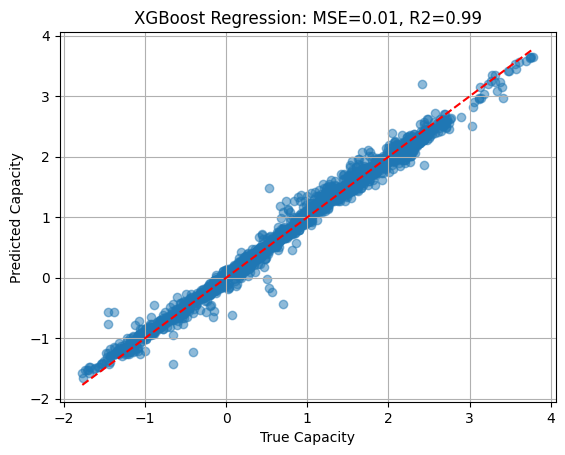

In [6]:
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('True Capacity')
plt.ylabel('Predicted Capacity')
plt.title(f'XGBoost Regression: MSE={mse:.2f}, R2={r2:.2f}')
plt.grid()
plt.show()

In [7]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f'Random Forest Regression: MSE={mse_rf:.2f}, R2={r2_rf:.2f}')

Random Forest Regression: MSE=0.01, R2=0.99


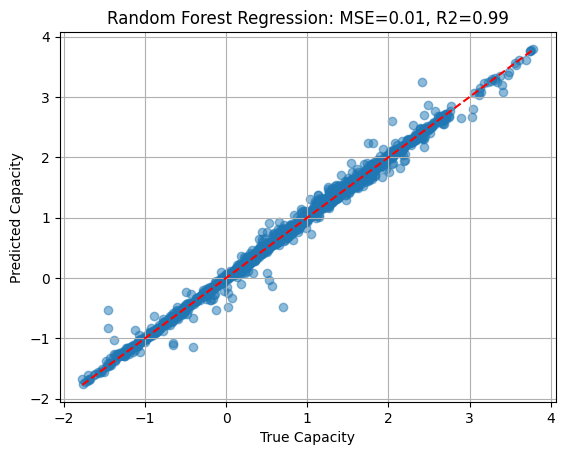

In [9]:
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('True Capacity')
plt.ylabel('Predicted Capacity')
plt.title(f'Random Forest Regression: MSE={mse_rf:.2f}, R2={r2_rf:.2f}')
plt.grid()
plt.show()

In [7]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(n_jobs=-1)
lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_test)
mse_lgbm = mean_squared_error(y_test, y_pred_lgbm)
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print(f'LightGBM Regression: MSE={mse_lgbm:.2f}, R2={r2_lgbm:.2f}')


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009106 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1719
[LightGBM] [Info] Number of data points in the train set: 10756, number of used features: 738
[LightGBM] [Info] Start training from score 0.781101
LightGBM Regression: MSE=0.01, R2=0.99


/opt/miniconda3/envs/bin-int/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


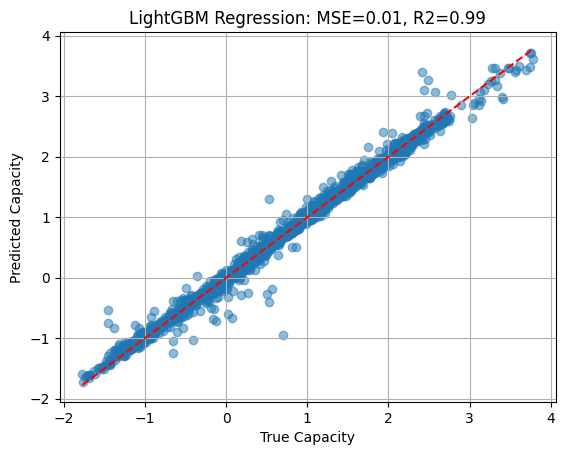

In [8]:
plt.scatter(y_test, y_pred_lgbm, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('True Capacity')
plt.ylabel('Predicted Capacity')
plt.title(f'LightGBM Regression: MSE={mse_lgbm:.2f}, R2={r2_lgbm:.2f}')
plt.grid()
plt.show()

In [14]:
# xgb hyperparameter optimization 
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42, 
        'n_jobs': -1
    }

    model = xgb.XGBRegressor(**param)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
    return -scores.mean()

study = optuna.create_study(direction='minimize', study_name='sol_ecfp_xgb', storage='sqlite:///ecfp.db', load_if_exists=True)
study.optimize(objective, n_trials=25)
print("Best hyperparameters:", study.best_params)

best_params_xgb = study.best_params

with open('best_params_xgb.pkl', 'wb') as f:
    pickle.dump(best_params_xgb, f)

[I 2025-11-06 19:04:54,747] A new study created in RDB with name: sol_ecfp_xgb
[I 2025-11-06 19:06:28,255] Trial 0 finished with value: 0.025308753159313108 and parameters: {'n_estimators': 273, 'learning_rate': 0.016079586784194414, 'max_depth': 6, 'subsample': 0.58089597069959, 'colsample_bytree': 0.5264377902133766}. Best is trial 0 with value: 0.025308753159313108.
[I 2025-11-06 19:07:01,100] Trial 1 finished with value: 0.005520646967686826 and parameters: {'n_estimators': 52, 'learning_rate': 0.09483719352882912, 'max_depth': 10, 'subsample': 0.5219665288684947, 'colsample_bytree': 0.9220474385936976}. Best is trial 1 with value: 0.005520646967686826.
[I 2025-11-06 19:07:57,040] Trial 2 finished with value: 0.006176559109213817 and parameters: {'n_estimators': 225, 'learning_rate': 0.1990427581837785, 'max_depth': 5, 'subsample': 0.5417994713225369, 'colsample_bytree': 0.9194957817792557}. Best is trial 1 with value: 0.005520646967686826.
[I 2025-11-06 19:08:38,077] Trial 3 finis

Best hyperparameters: {'n_estimators': 296, 'learning_rate': 0.17791605255630222, 'max_depth': 9, 'subsample': 0.7760762836120885, 'colsample_bytree': 0.7635908430923144}


In [9]:
# lgbm model hyperparameter optimization
def objective(trial):
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42,
        'verbosity': -1,
        'n_jobs': -1
    }

    model = LGBMRegressor(**param)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    score = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
    return -score.mean()

study = optuna.create_study(direction='minimize', study_name='sol_ecfp_lgbm', storage='sqlite:///ecfp.db', load_if_exists=True)
study.optimize(objective, n_trials=25)
print("Best hyperparameters:", study.best_params)

best_params_lgbm = study.best_params
with open('best_params_lgbm.pkl', 'wb') as f:
    pickle.dump(best_params_lgbm, f)


[I 2025-11-06 19:38:36,992] Using an existing study with name 'sol_ecfp_lgbm' instead of creating a new one.
/opt/miniconda3/envs/bin-int/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/bin-int/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/bin-int/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/bin-int/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/miniconda3/envs/bin-int/lib/python3.12/site-packages/sklea

Best hyperparameters: {'n_estimators': 229, 'learning_rate': 0.2608330849911035, 'max_depth': 10, 'num_leaves': 86, 'subsample': 0.6408592037119448, 'colsample_bytree': 0.6777596410279507}


In [13]:
from sklearn.ensemble import VotingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor

best_params_xgb = pickle.load(open('best_params_xgb.pkl', 'rb'))
best_params_lgbm = pickle.load(open('best_params_lgbm.pkl', 'rb'))
model = VotingRegressor(
    estimators = [
        ('xgb', xgb.XGBRegressor(**best_params_xgb)),
        ('rf', RandomForestRegressor()),
        ('lgbm', LGBMRegressor(**best_params_lgbm))
    ]
)

model.fit(X, y)
with open('voting_regressor_model.pkl', 'wb') as f:
    pickle.dump(model, f)


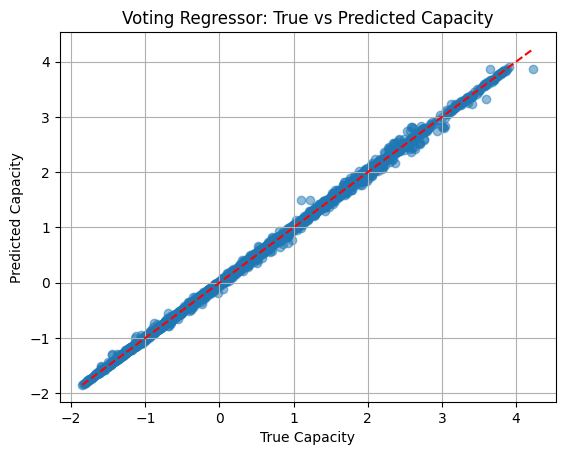

In [47]:
plt.scatter(y, model.predict(X), alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('True Capacity') 
plt.ylabel('Predicted Capacity')
plt.title('Voting Regressor: True vs Predicted Capacity')
plt.grid()
plt.show()

In [48]:
sorted_data.head()

,Cation,Anion,Capacity,Cation_SMILES,Anion_SMILES
618,methyltris(2-methylpropyl)phosphonium,fluoride,17004.400,CC(C)C[P+](C)(CC(C)C)CC(C)C,[F-]
2360,tetrapropylammonium,fluoride,7989.210,CCC[N+](CCC)(CCC)CCC,[F-]
867,tributyl-ethyl-phosphonium,fluoride,7440.901,CCCC[P+](CC)(CCCC)CCCC,[F-]
2194,tetra-n-butylammonium,fluoride,7190.077,CCCC[N+](CCCC)(CCCC)CCCC,[F-]
12237,"1,1-dipropyl-pyrrolidinium",fluoride,7079.859,CCC[N+]1(CCC)CCCC1,[F-]


In [40]:
sorted_data = data.sort_values(by='Capacity', ascending=False)
groupby_cation = sorted_data.groupby('Cation')
groupby_anion = sorted_data.groupby('Anion')

visited_cations = set()
visited_anions = set()

cation_samples = []
anion_samples = []
n_samples = 3
for name, group in groupby_cation:
    if name not in visited_cations:
        for i in range(min(n_samples, len(group))):
            cation_samples.append(group.iloc[i])
        visited_cations.add(name)
for name, group in groupby_anion:
    if name not in visited_anions:
        for i in range(min(n_samples, len(group))):
            anion_samples.append(group.iloc[i])
        visited_anions.add(name)

cation_samples_df = pd.DataFrame(cation_samples)
anion_samples_df = pd.DataFrame(anion_samples)

combined_samples_df = pd.concat([cation_samples_df, anion_samples_df]).drop_duplicates(subset=['Cation', 'Anion']).reset_index(drop=True)

print(combined_samples_df.shape)
display(combined_samples_df.head(10))

(726, 5)


,Cation,Anion,Capacity,Cation_SMILES,Anion_SMILES
0,(2-ethoxyethyl)-ethyl-dimethylammonium,fluoride,3114.3540,CCOCC[N+](C)(C)CC,[F-]
1,(2-ethoxyethyl)-ethyl-dimethylammonium,sulfate,410.6627,CCOCC[N+](C)(C)CC,[O-][S]([O-])(=O)=O
2,(2-ethoxyethyl)-ethyl-dimethylammonium,acetate,286.0158,CCOCC[N+](C)(C)CC,CC([O-])=O
3,"1,1-dihexylpyrrolidinium",fluoride,5371.5130,CCCCCC[N+]1(CCCCCC)CCCC1,[F-]
4,"1,1-dihexylpyrrolidinium",sulfate,516.8159,CCCCCC[N+]1(CCCCCC)CCCC1,[O-][S]([O-])(=O)=O
5,"1,1-dihexylpyrrolidinium",propanoate,465.9184,CCCCCC[N+]1(CCCCCC)CCCC1,CCC([O-])=O
6,"1,1-dimethyl-pyrrolidinium",fluoride,3914.5510,C[N+]1(C)CCCC1,[F-]
7,"1,1-dimethyl-pyrrolidinium",sulfate,513.3622,C[N+]1(C)CCCC1,[O-][S]([O-])(=O)=O
8,"1,1-dimethyl-pyrrolidinium",acetate,331.5458,C[N+]1(C)CCCC1,CC([O-])=O
9,"1,1-dipropyl-pyrrolidinium",fluoride,7079.8590,CCC[N+]1(CCC)CCCC1,[F-]


In [42]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
import numpy as np

def get_fragments(smiles):
    mol_dm = dm.to_mol(smiles)
    frag_list = dm.fragment.frag(mol_dm, remove_parent=True)
    frags_dm = set(dm.to_smiles(frag) for frag in frag_list)
    return frags_dm

def get_residual(parent_smiles, fragment_smiles):
    parent = Chem.MolFromSmiles(parent_smiles)
    fragment = Chem.MolFromSmiles(fragment_smiles)
    
    # Remove the substructure
    residual = Chem.DeleteSubstructs(parent, fragment)
    
    # Get all disconnected fragments
    frags = Chem.GetMolFrags(residual, asMols=True, sanitizeFrags=True)
    
    # If no fragments remain, return empty string or None
    if not frags:
        return None
    
    # Select the largest fragment by number of atoms
    largest_frag = max(frags, key=lambda m: m.GetNumAtoms())
    
    return Chem.MolToSmiles(largest_frag)

def get_frag_contribs(cation_smiles, anion_smiles, model):

    ref_input = np.hstack((generate_ecfp(cation_smiles), generate_ecfp(anion_smiles)))
    ref_pred = model.predict(ref_input.reshape(1, -1))[0]

    contribs_cation = {}
    contribs_anion = {}

    cation_frag_list = get_fragments(cation_smiles)
    # print("Cation fragments:", cation_frag_list)
    
    for frag in cation_frag_list:
        residual_cation = get_residual(cation_smiles, frag)
        if residual_cation is None:
            continue
        pred_input = np.hstack((generate_ecfp(residual_cation), generate_ecfp(anion_smiles)))
        new_pred = model.predict(pred_input.reshape(1, -1))[0]
        delta = new_pred - ref_pred
        contribs_cation[frag] = float(delta)

    anion_frag_list = get_fragments(anion_smiles)
    # print("Anion fragments:", anion_frag_list)
    for frag in anion_frag_list:
        residual_anion = get_residual(anion_smiles, frag)
        if residual_anion is None:
            continue
        pred_input = np.hstack((generate_ecfp(cation_smiles), generate_ecfp(residual_anion)))
        new_pred = model.predict(pred_input.reshape(1, -1))[0]
        delta = new_pred - ref_pred
        contribs_anion[frag] = float(delta)
        
    return contribs_cation, contribs_anion

def visualize_fragment_contributions(smiles, contribs):
    """
    Visualize fragment contributions using RDKit's SimilarityMaps.
    """
    mol = Chem.MolFromSmiles(smiles)
    
    # Map contributions to atoms
    atom_contribs = [0.0] * mol.GetNumAtoms()
    atom_counts = [0] * mol.GetNumAtoms()
    
    for frag_smiles, score in contribs.items():
        frag_mol = Chem.MolFromSmiles(frag_smiles)
        if frag_mol is None:
            continue
        matches = mol.GetSubstructMatches(frag_mol)
        for match in matches:
            for atom_idx in match:
                atom_contribs[atom_idx] += score
                atom_counts[atom_idx] += 1
    
    # Average and normalize
    atom_contribs = [
        contrib / count if count > 0 else 0 
        for contrib, count in zip(atom_contribs, atom_counts)
    ]

    max_contrib = max(abs(c) for c in atom_contribs) or 1
    norm_contribs = [c / max_contrib for c in atom_contribs]

    # Use RDKit SimilarityMap with Cairo drawer
    drawer = Draw.rdMolDraw2D.MolDraw2DCairo(400, 400)
    SimilarityMaps.GetSimilarityMapFromWeights(
        mol,
        norm_contribs,
        colorMap='coolwarm',
        contourLines=10,
        alpha=0.5,
        draw2d=drawer
    )
    drawer.FinishDrawing()

    # Convert to image
    png = drawer.GetDrawingText()
    
    img = Image.open(io.BytesIO(png))

    # plt.imshow(img)
    # plt.axis('off')
    # plt.title(f'Fragment Contribution Heatmap\n{smiles}', pad=20)
    # plt.tight_layout()
    # plt.show()

    return atom_contribs, img

# smiles_cation = top_entries.iloc[0]['Cation_SMILES']
# smiles_anion = top_entries.iloc[0]['Anion_SMILES']
# print("Cation SMILES:", smiles_cation)
# print("Anion SMILES:", smiles_anion)
# contrib_cation, contrib_anion = get_frag_contribs(smiles_cation, smiles_anion, xgb_model)
# print("Cation Fragment Contributions:", contrib_cation)
# print("Anion Fragment Contributions:", contrib_anion)

In [ ]:
import warnings
warnings.filterwarnings("ignore")
model = pickle.load(open('voting_regressor_model.pkl', 'rb'))

frag_contrib_path = './fragment_contribs'
for index, entry in combined_samples_df.iterrows():
    smiles_cation = entry['Cation_SMILES']
    smiles_anion = entry['Anion_SMILES']
    cation_label = f"Cation: {entry['Cation']}"
    capacity = entry['Capacity']
    contribs_cation, contribs_anion = get_frag_contribs(smiles_cation, smiles_anion, model)
    cation_contribs, img_cation = visualize_fragment_contributions(smiles_cation, contribs_cation)
    anion_contribs, img_anion = visualize_fragment_contributions(smiles_anion, contribs_anion)
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(img_cation)
    ax[0].axis('off')
    ax[0].set_title(f"{cation_label}")
    ax[1].imshow(img_anion)
    ax[1].axis('off')
    ax[1].set_title(f"Anion: {entry['Anion']}")
    fig.suptitle('Fragment Contribution Heatmaps', fontsize=16)
    fig.text(0.5, 0.04, f'True log(Capacity): {np.log10(capacity):.2f}', ha='center', fontsize=12)
    plt.savefig(os.path.join(frag_contrib_path, f'{entry["Cation"]}_{entry["Anion"]}_fragment_contrib.png'))
    plt.close()

ValueError: Feature shape mismatch, expected: 1536, got 4096

In [ ]:
frag_contrib_path = './fragment_contribs'
for index, entry in top_organic_entries.iterrows():
    smiles_cation = entry['Cation_SMILES']
    smiles_anion = entry['Anion_SMILES']
    cation_label = f"Cation: {entry['Cation']}"
    anion_label =  f"Anion: {entry['Anion']}"
    capacity = entry['Capacity']
    contribs_cation, contribs_anion = get_frag_contribs(smiles_cation, smiles_anion, xgb_model)
    cation_contribs, img_cation = visualize_fragment_contributions(smiles_cation, contribs_cation)
    anion_contribs, img_anion = visualize_fragment_contributions(smiles_anion, contribs_anion)

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    fig.title(f'{cation_label} {anion_label}')
    axs[0].imshow(img_cation)
    axs[0].axis('off')
    axs[1].imshow(img_anion)
    axs[1].axis('off')

    fig.text(0.5, 0.04, f'True log(Capacity): {np.log10(capacity):.2f}', ha='center', fontsize=12)
    plt.savefig(os.path.join(frag_contrib_path, f'{entry["Cation"]}_{entry["Anion"]}_fragment_contrib.png'))
    plt.close()

Cation fragments: {'CC(C)C', 'CCC', 'CC(C)C[P+](C)(C)CC(C)C', 'CC(C)C[PH+](C)CC(C)C'}
Anion fragments: {'O=C[O-]'}
Cation fragments: {'CC(C)C', 'CCC', 'CC(C)C[P+](C)(C)CC(C)C', 'CC(C)C[PH+](C)CC(C)C'}
Anion fragments: set()
Cation fragments: {'CC(C)C', 'CCC', 'CC(C)C[P+](C)(C)CC(C)C', 'CC(C)C[PH+](C)CC(C)C'}
Anion fragments: {'CC(=O)[O-]', 'CCC', 'O=C[O-]'}
Cation fragments: {'CC(C)C', 'CCC', 'CC(C)C[P+](C)(C)CC(C)C', 'CC(C)C[PH+](C)CC(C)C'}
Anion fragments: {'O=C[O-]', 'CCCCCCC(=O)[O-]', 'CCCCC', 'CCCCCCCC', 'CCCCCCCC(=O)[O-]', 'CCCC', 'CC(=O)[O-]', 'CCC(=O)[O-]', 'CCCC(=O)[O-]', 'CCCCC(=O)[O-]', 'CCCCCCC', 'CCCCCC(=O)[O-]', 'CCCCCCCCC', 'CCCCCC', 'CCC'}
Cation fragments: {'CCC[NH+](CCC)CCC', 'CCC', 'CCC[N+](C)(CCC)CCC'}
Anion fragments: {'O=C[O-]'}
Cation fragments: {'CCCC[P+](C)(CC)CCCC', 'CCCC', 'CCCC[P+](CC)(CC)CCCC', 'CCCC[PH+](CCCC)CCCC', 'CCCC[PH+](CC)CCCC', 'CCC'}
Anion fragments: {'O=C[O-]'}
Cation fragments: {'CCC[NH+](CCC)CCC', 'CCC', 'CCC[N+](C)(CCC)CCC'}
Anion fragments: 

In [63]:
def get_ecfp_bit_contributions(cation_smiles, anion_smiles, model, radius=2, nBits=2048):
    from rdkit import Chem
    from rdkit.Chem import AllChem
    import numpy as np

    cation = Chem.MolFromSmiles(cation_smiles)
    anion = Chem.MolFromSmiles(anion_smiles)
    if cation is None or anion is None:
        raise ValueError("Invalid SMILES string")

    # Generate fingerprints with bit info
    cation_info, anion_info = {}, {}
    fp_cation = AllChem.GetMorganFingerprintAsBitVect(cation, radius, nBits=nBits, bitInfo=cation_info)
    fp_anion = AllChem.GetMorganFingerprintAsBitVect(anion, radius, nBits=nBits, bitInfo=anion_info)
    fp = np.hstack((np.array(fp_cation), np.array(fp_anion, dtype=int)))

    base_pred = model.predict(fp.reshape(1, -1))[0]
    cationic_contributions, anionic_contributions = [], []

    # --- Helper function ---
    def compute_contributions(mol, fp_mol, fp_other, bit_info, is_cation=True):
        contributions = []
        for bit_id, atom_envs in bit_info.items():
            atom_id, radius_bit = atom_envs[0]  # (atom_idx, radius)
            env = Chem.FindAtomEnvironmentOfRadiusN(mol, radius_bit, atom_id)
            if not env:
                continue
            atoms_in_env = set()
            for b in env:
                bond = mol.GetBondWithIdx(b)
                atoms_in_env.add(bond.GetBeginAtomIdx())
                atoms_in_env.add(bond.GetEndAtomIdx())

            submol = Chem.PathToSubmol(mol, env)
            frag_smiles = Chem.MolToSmiles(submol)

            # Zero out this bit
            fp_mod = np.array(fp_mol, dtype=int)
            fp_mod[bit_id] = 0
            if is_cation:
                test = np.hstack((fp_mod, np.array(fp_other, dtype=int)))
            else:
                test = np.hstack((np.array(fp_other, dtype=int), fp_mod))
            new_pred = model.predict(test.reshape(1, -1))[0]
            delta = new_pred - base_pred

            contributions.append({
                "bit_id": bit_id,
                "delta_value": float(delta),
                "atom_ids": list(atoms_in_env),
                "fragment_smiles": frag_smiles
            })
        return sorted(contributions, key=lambda x: -abs(x["delta_value"]))

    cationic_contributions = compute_contributions(cation, fp_cation, fp_anion, cation_info, is_cation=True)
    anionic_contributions = compute_contributions(anion, fp_anion, fp_cation, anion_info, is_cation=False)

    return cationic_contributions, anionic_contributions, base_pred

smiles_cation = top_entries.iloc[0]['Cation_SMILES']
smiles_anion = top_entries.iloc[0]['Anion_SMILES']

contribs_cation, contribs_anion, base_pred_cation = get_ecfp_bit_contributions(smiles_cation, smiles_anion, xgb_model)

In [64]:
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image
import io
import numpy as np

def visualize_full_contributions(smiles, contributions, scale='coolwarm', size=(400, 400)):
    mol = Chem.MolFromSmiles(smiles)
    n_atoms = mol.GetNumAtoms()

    # Aggregate contributions per atom
    atom_contribs = np.zeros(n_atoms)
    for c in contributions:
        delta = c.get("delta_value", 0.0)
        atoms = c.get("atom_ids", [])
        if isinstance(atoms, int):
            atoms = [atoms]
        for a in atoms:
            if 0 <= a < n_atoms:
                atom_contribs[a] += delta

    # Normalize contributions for color mapping
    max_abs = np.max(np.abs(atom_contribs))
    if max_abs < 1e-6:
        max_abs = 1e-6
    normalized = atom_contribs / max_abs

    # Apply a continuous color scale for all atoms
    cmap = plt.get_cmap(scale)
    atom_colors = {
        i: tuple(cmap((val + 1) / 2)[:3])  # RGB tuple
        for i, val in enumerate(normalized)
    }

    # Draw molecule
    drawer = rdMolDraw2D.MolDraw2DCairo(size[0], size[1])
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer,
        mol,
        highlightAtoms=list(range(n_atoms)),
        highlightAtomColors=atom_colors,
        highlightBondColors=atom_colors,
        highlightAtomRadii={i: 0.45 for i in range(n_atoms)}
    )
    drawer.FinishDrawing()

    img = Image.open(io.BytesIO(drawer.GetDrawingText()))
    return img


In [66]:
ecfp_output_path = './ecfp_bit_contribution_outputs'
for index, entry in top_entries.iterrows():
    smiles_cation = entry['Cation_SMILES']
    smiles_anion = entry['Anion_SMILES']
    cation_label = f"Cation: {entry['Cation']}"
    capacity = entry['Capacity']
    contribs_cation, contribs_anion, base_pred = get_ecfp_bit_contributions(smiles_cation, smiles_anion, xgb_model)
    print("base pred:", base_pred, "true pred:", np.log10(capacity))
    img_cation = visualize_full_contributions(smiles_cation, contribs_cation)
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    plt.imshow(img_cation)
    plt.axis('off')
    plt.title(f"{cation_label}")
    fig.text(0.5, 0.04, f'True log(Capacity): {np.log10(capacity):.2f}, Predicted log(Capacity): {base_pred:.2f}', ha='center', fontsize=12)
    plt.savefig(os.path.join(ecfp_output_path, f'{entry["Cation"]}_{entry["Anion"]}_ecfp_contrib.png'))
    plt.close()

base pred: 3.3796852 true pred: 4.230561312464783
base pred: 3.3606725 true pred: 3.9025038369356158
base pred: 3.4620204 true pred: 3.871625526357238
base pred: 3.347307 true pred: 3.856733541355907
base pred: 3.407086 true pred: 3.8500246085186225
base pred: 3.4395173 true pred: 3.8313664302624058
base pred: 3.350072 true pred: 3.8252732763455053
base pred: 3.446949 true pred: 3.815736163867932
base pred: 3.4297001 true pred: 3.8145287969443116
base pred: 3.4297001 true pred: 3.8066941727056216
base pred: 3.4315562 true pred: 3.804674641370454
base pred: 3.4293735 true pred: 3.8006313791282533
base pred: 3.3981442 true pred: 3.800205519054651
base pred: 3.3335545 true pred: 3.7986727393561135
base pred: 3.4293735 true pred: 3.7933005148011376
base pred: 3.4293735 true pred: 3.782877418646172
base pred: 3.4293735 true pred: 3.771238361830695
base pred: 3.317041 true pred: 3.762973693663678
base pred: 3.317041 true pred: 3.761353784735052
base pred: 3.4293735 true pred: 3.7541488814650

In [67]:
for index, entry in top_organic_entries.iterrows():
    smiles_cation = entry['Cation_SMILES']
    smiles_anion = entry['Anion_SMILES']
    cation_label = f"Cation: {entry['Cation']}"
    capacity = entry['Capacity']
    contribs_cation, contribs_anion, base_pred = get_ecfp_bit_contributions(smiles_cation, smiles_anion, xgb_model)
    print("base pred:", base_pred, "true pred:", np.log10(capacity))
    img_cation = visualize_full_contributions(smiles_cation, contribs_cation)
    img_anion = visualize_full_contributions(smiles_anion, contribs_anion)
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    
    axs[0].imshow(img_cation)
    axs[0].axis('off')
    axs[0].set_title(f"{cation_label}")
    axs[1].imshow(img_anion)
    axs[1].axis('off')
    axs[1].set_title(f"Anion: {entry['Anion']}")
    fig.text(0.5, 0.04, f'True log(Capacity): {np.log10(capacity):.2f}, Predicted log(Capacity): {base_pred:.2f}', ha='center', fontsize=12)
    plt.savefig(os.path.join(frag_contrib_path, f'{entry["Cation"]}_{entry["Anion"]}_fragment_contrib.png'))
    plt.close()

base pred: 2.1623802 true pred: 3.0304276700384043
base pred: 2.2580862 true pred: 3.0186493287732508
base pred: 2.1877759 true pred: 3.0018898404271486
base pred: 2.1122525 true pred: 2.9392690868623292
base pred: 2.0981364 true pred: 2.773194846065686
base pred: 2.252164 true pred: 2.7681440415607335
base pred: 2.1801827 true pred: 2.765277662850714
base pred: 1.9865196 true pred: 2.7625373012895746
base pred: 2.0343955 true pred: 2.7609391070921547
base pred: 2.3257499 true pred: 2.7551499697626394
base pred: 2.1784298 true pred: 2.7546266384597105
base pred: 2.2101219 true pred: 2.748839987308237
base pred: 2.075358 true pred: 2.7473760684084505
base pred: 2.2239528 true pred: 2.7450482331937804
base pred: 2.0844765 true pred: 2.7339302907353615
base pred: 2.1420016 true pred: 2.7273518015069556
base pred: 2.2304251 true pred: 2.7263996127957735
base pred: 2.1654868 true pred: 2.7217874577167076
base pred: 2.1534932 true pred: 2.715859334436801
base pred: 2.090782 true pred: 2.7153

In [16]:
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image
import io
import numpy as np
import matplotlib.cm as cm
from collections import defaultdict

def aggregate_atom_contributions_from_bits(smiles, contributions):
    """
    Given SMILES and a list of bit-level contributions (your format),
    return a numpy array of length n_atoms with the summed contributions per atom.
    contributions: list of dicts with keys "delta_value" and "atom_ids" (int or list).
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES")
    n = mol.GetNumAtoms()
    atom_contribs = np.zeros(n, dtype=float)

    for c in contributions:
        delta = float(c.get("delta_value", 0.0))
        atoms = c.get("atom_ids", [])

        if isinstance(atoms, int):
            atoms = [atoms]
        for a in atoms:
            if 0 <= a < n:
                atom_contribs[a] += delta
    return atom_contribs

def symmetrize_and_visualize(smiles, atom_contribs, cmap='seismic', size=(400, 400), show_atom_labels=False):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES")

    n = mol.GetNumAtoms()
    if len(atom_contribs) != n:
        raise ValueError("Length mismatch between atom_contribs and molecule atoms")
    
    ranks = list(Chem.CanonicalRankAtoms(mol))
    groups = defaultdict(list)
    for idx, r in enumerate(ranks):
        groups[r].append(idx)

    sym_contribs = atom_contribs.copy()
    for r, atom_list in groups.items():
        avg = float(np.mean(atom_contribs[atom_list]))
        for a in atom_list:
            sym_contribs[a] = avg

    max_abs = np.max(np.abs(sym_contribs)) or 1e-12
    normalized = sym_contribs / max_abs
    cmap_obj = cm.get_cmap(cmap)
    atom_colors = {i: tuple(cmap_obj((val + 1) / 2)[:3]) for i, val in enumerate(normalized)}

    drawer = rdMolDraw2D.MolDraw2DCairo(size[0], size[1])
    opts = drawer.drawOptions()

    if show_atom_labels:
        for i, val in enumerate(sym_contribs):
            opts.atomLabels[i] = f"{val:.2f}"

    highlight_atoms = list(range(n))
    highlight_bonds = []
    highlight_radii = {i: 0.45 for i in range(n)}

    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer,
        mol,
        "",
        highlight_atoms,
        highlight_bonds,
        atom_colors,
        atom_colors,
        highlight_radii,
        -1,
        True
    )

    drawer.FinishDrawing()
    img = Image.open(io.BytesIO(drawer.GetDrawingText()))
    return img, sym_contribs


atom_contribs = aggregate_atom_contributions_from_bits(smiles_cation, contribs_cation)
img, sym_contribs = symmetrize_and_visualize(smiles_cation, atom_contribs,
                                             cmap='coolwarm',
                                             show_atom_labels=False)
img.show()

/var/folders/7l/2100442d14j36v6s7s59lflm0000gn/T/ipykernel_60956/1956120896.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = cm.get_cmap(cmap)


base pred: 3.3796852 true pred: 4.230561312464783


/var/folders/7l/2100442d14j36v6s7s59lflm0000gn/T/ipykernel_60956/1956120896.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_obj = cm.get_cmap(cmap)


<Figure size 800x800 with 0 Axes>

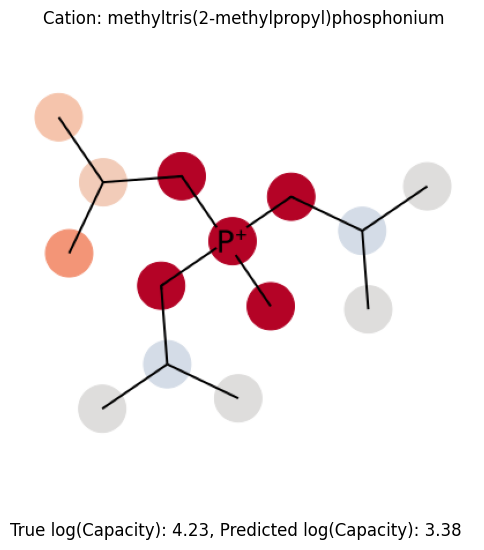

base pred: 3.3606725 true pred: 3.9025038369356158


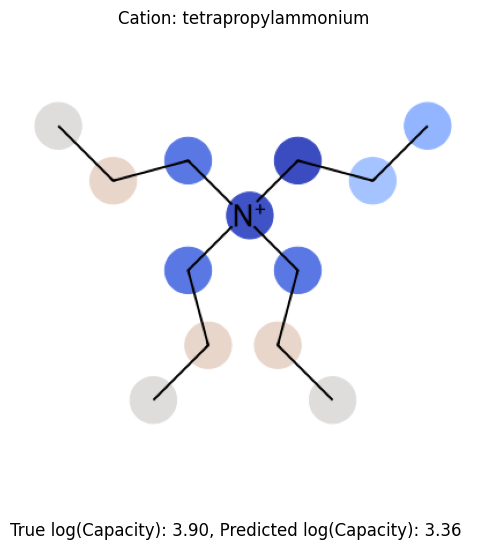

base pred: 3.4620204 true pred: 3.871625526357238


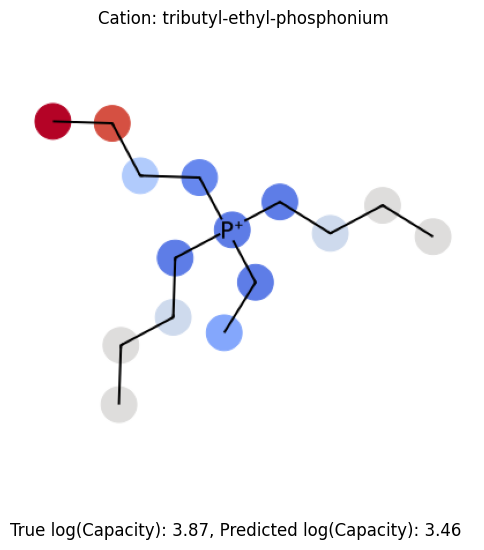

base pred: 3.347307 true pred: 3.856733541355907


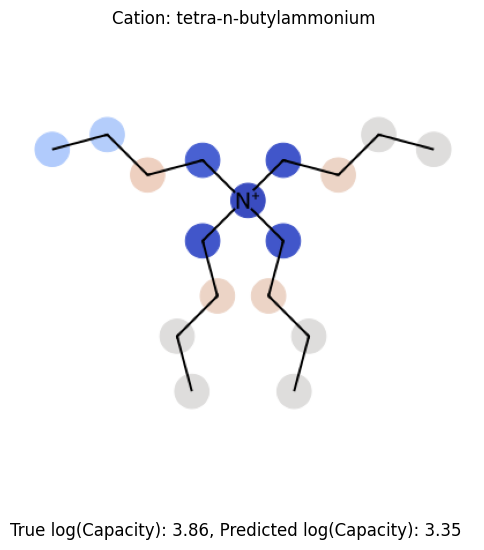

base pred: 3.407086 true pred: 3.8500246085186225


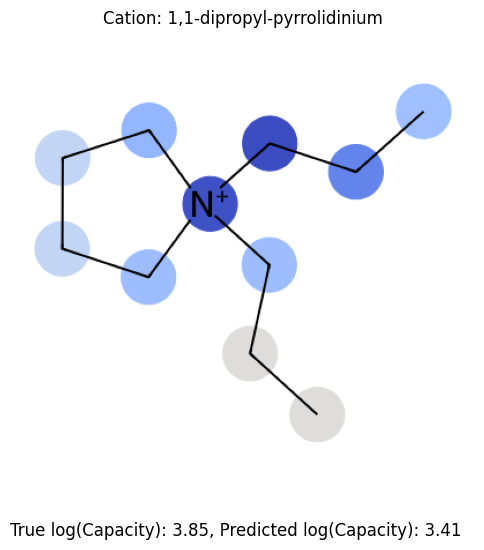

base pred: 3.4395173 true pred: 3.8313664302624058


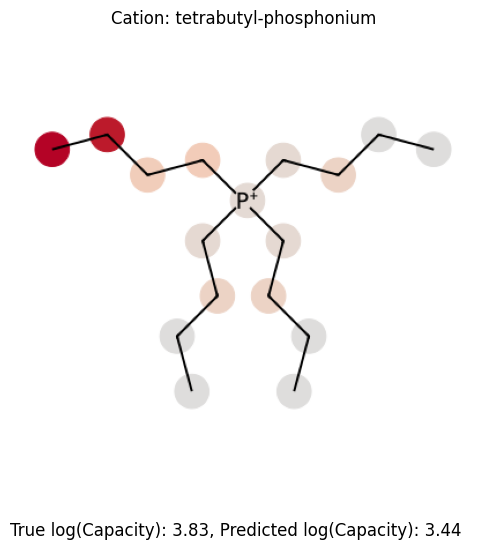

base pred: 3.350072 true pred: 3.8252732763455053


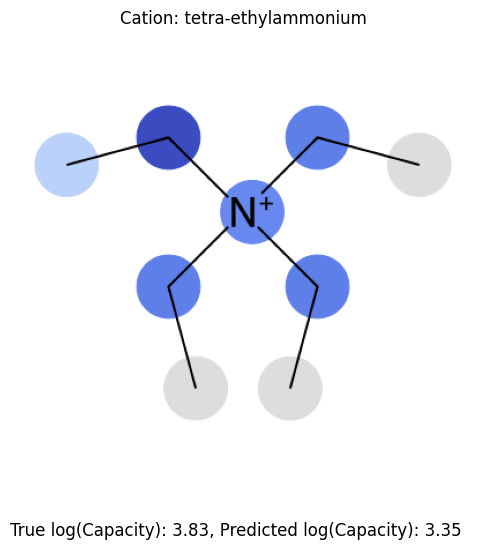

base pred: 3.446949 true pred: 3.815736163867932


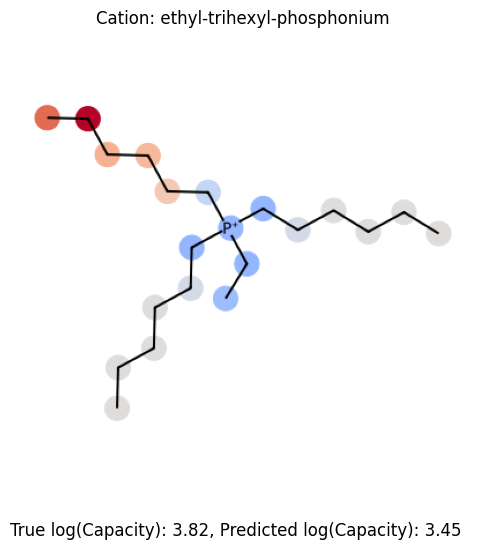

base pred: 3.4297001 true pred: 3.8145287969443116


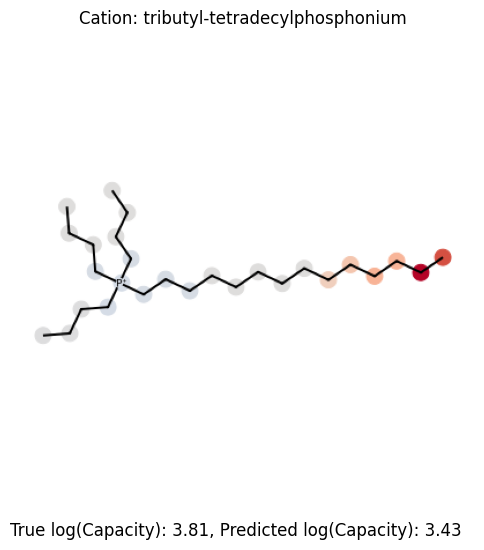

base pred: 3.4297001 true pred: 3.8066941727056216


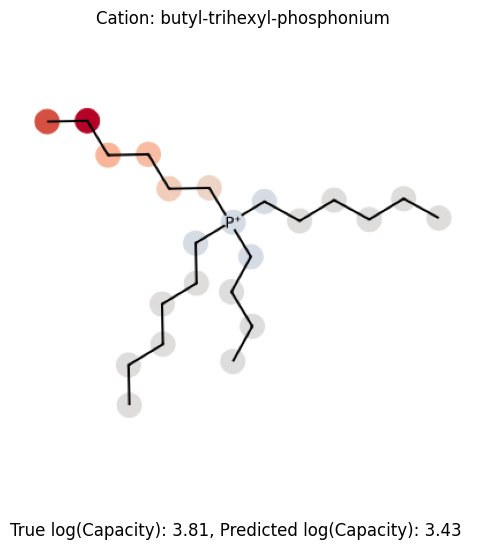

base pred: 3.4315562 true pred: 3.804674641370454


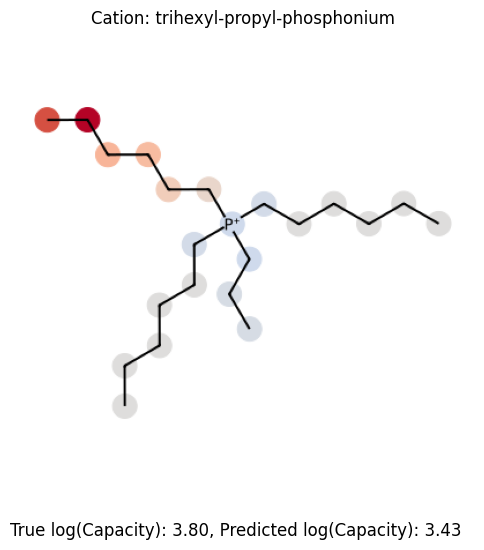

base pred: 3.4293735 true pred: 3.8006313791282533


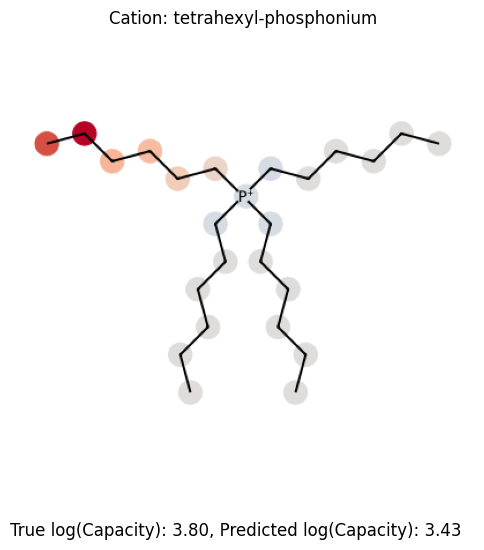

base pred: 3.3981442 true pred: 3.800205519054651


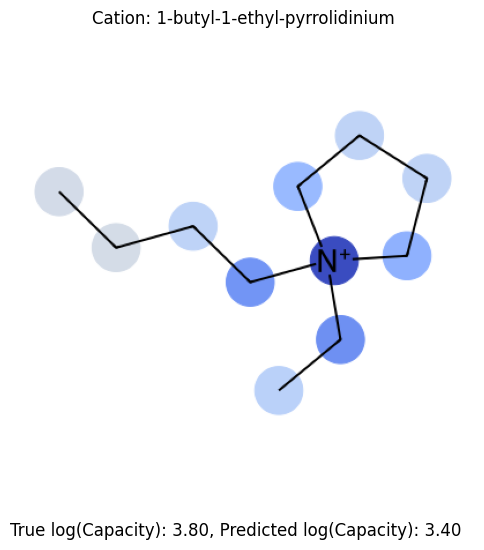

base pred: 3.3335545 true pred: 3.7986727393561135


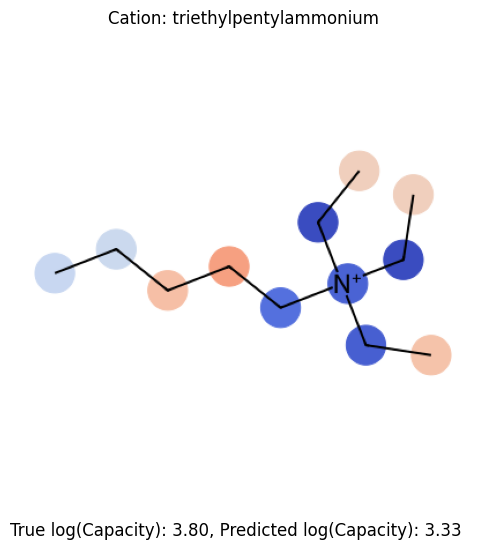

base pred: 3.4293735 true pred: 3.7933005148011376


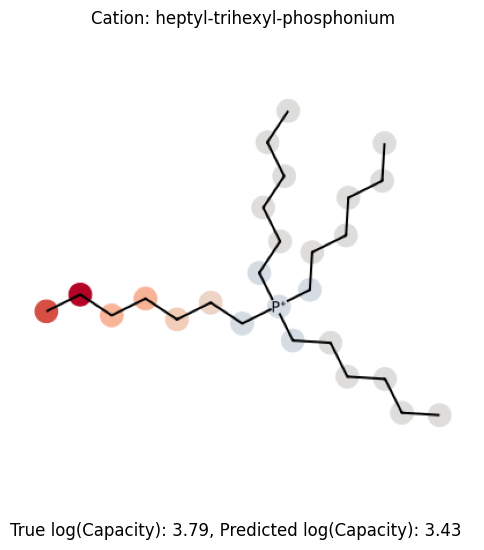

base pred: 3.4293735 true pred: 3.782877418646172


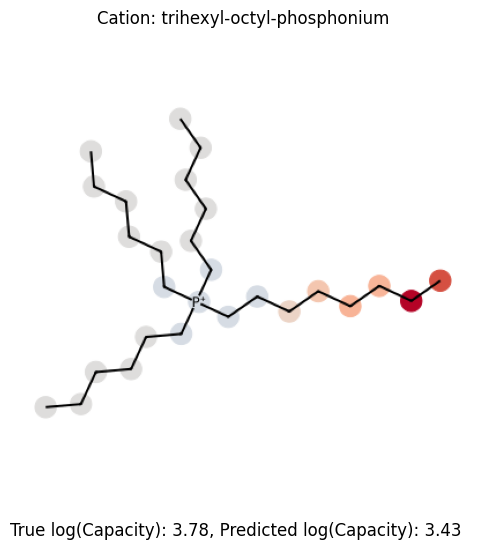

base pred: 3.4293735 true pred: 3.771238361830695


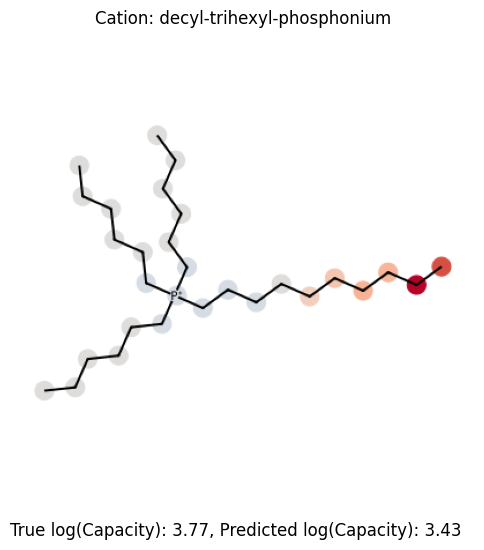

base pred: 3.317041 true pred: 3.762973693663678


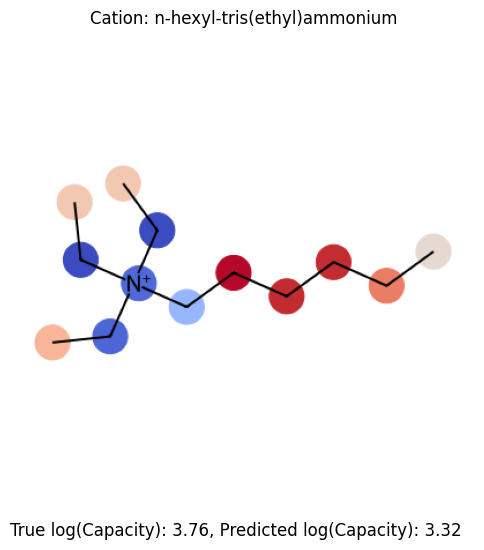

base pred: 3.317041 true pred: 3.761353784735052


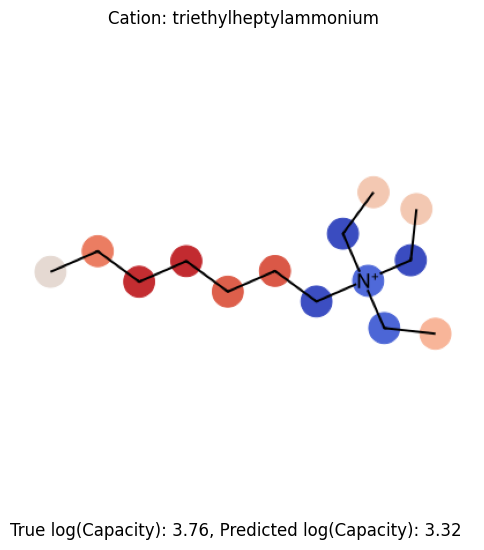

base pred: 3.4293735 true pred: 3.7541488814650594


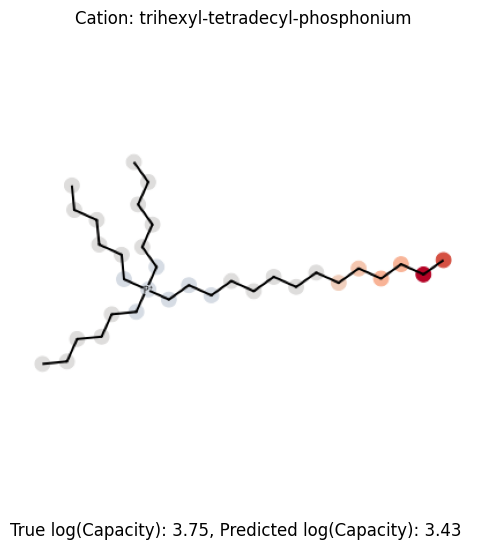

In [17]:
plt.figure(figsize=(8, 8))
for index, entry in top_entries.iterrows():
    smiles_cation = entry['Cation_SMILES']
    smiles_anion = entry['Anion_SMILES']
    cation_label = f"Cation: {entry['Cation']}"
    capacity = entry['Capacity']
    contribs_cation, contribs_anion, base_pred = get_ecfp_bit_contributions(smiles_cation, smiles_anion, xgb_model)
    atom_contribs = aggregate_atom_contributions_from_bits(smiles_cation, contribs_cation)

    print("base pred:", base_pred, "true pred:", np.log10(capacity))
    img, sym_contribs = symmetrize_and_visualize(smiles_cation, atom_contribs,
                                             cmap='coolwarm',
                                             show_atom_labels=False)
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{cation_label}")
    fig.text(0.5, 0.04, f'True log(Capacity): {np.log10(capacity):.2f}, Predicted log(Capacity): {base_pred:.2f}', ha='center', fontsize=12)
    plt.show()

In [40]:
import rdkit
from rdkit import Chem
from rdkit.Chem import BRICS
import datamol as dm

def get_residual(parent_smiles, fragment_smiles):
    parent = Chem.MolFromSmiles(parent_smiles)
    fragment = Chem.MolFromSmiles(fragment_smiles)
    
    # Remove the substructure
    residual = Chem.DeleteSubstructs(parent, fragment)
    
    # Get all disconnected fragments
    frags = Chem.GetMolFrags(residual, asMols=True, sanitizeFrags=True)
    
    # If no fragments remain, return empty string or None
    if not frags:
        return None
    
    # Select the largest fragment by number of atoms
    largest_frag = max(frags, key=lambda m: m.GetNumAtoms())
    
    return Chem.MolToSmiles(largest_frag)


smiles = "CC(C)C[P+](C)(CC(C)C)CC(C)C"
original_mol = dm.to_mol(smiles)
frag_list, frag_set, frag_tree = dm.fragment.break_mol(original_mol, returnTree=True, minFragmentSize=1)

def score_fragment(smiles):
    return len(smiles)  # Example: score based on fragment length

# remove only fragment from original molecule
for frag in frag_list:
    try:
        residual_smiles = get_residual(smiles, frag)
        frag_score = score_fragment(frag)
        print(f"Fragment: {frag}, Score: {frag_score}, Residual: {residual_smiles}")

    except Exception as e:
        print(f"Error processing fragment {frag}: {e}")

def get_frag_contribs(smiles):
    mol = dm.to_mol(smiles)
    contribs = {}
    frag_list, frag_set, _ = dm.fragment.break_mol(mol, returnTree=True, minFragmentSize=2)
    for frag in frag_list:
        residual_smiles = get_residual(smiles, frag)
        contribs[frag] = score_fragment(frag)
    return contribs

contribs = get_frag_contribs(smiles)
print(contribs)



{}


In [36]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import SimilarityMaps
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm, colors

def visualize_fragment_contributions(smiles, contribs):
    """
    Visualize fragment contributions using RDKit's SimilarityMaps.
    """
    mol = Chem.MolFromSmiles(smiles)
    
    # Map contributions to atoms
    atom_contribs = [0.0] * mol.GetNumAtoms()
    atom_counts = [0] * mol.GetNumAtoms()
    
    for frag_smiles, score in contribs.items():
        frag_mol = Chem.MolFromSmiles(frag_smiles)
        if frag_mol is None:
            continue
        matches = mol.GetSubstructMatches(frag_mol)
        for match in matches:
            for atom_idx in match:
                atom_contribs[atom_idx] += score
                atom_counts[atom_idx] += 1
    
    # Average and normalize
    atom_contribs = [
        contrib / count if count > 0 else 0 
        for contrib, count in zip(atom_contribs, atom_counts)
    ]
    max_contrib = max(abs(c) for c in atom_contribs) or 1
    norm_contribs = [c / max_contrib for c in atom_contribs]

    # Use RDKit SimilarityMap with Cairo drawer
    drawer = Draw.rdMolDraw2D.MolDraw2DCairo(400, 400)
    SimilarityMaps.GetSimilarityMapFromWeights(
        mol,
        norm_contribs,
        colorMap='coolwarm',
        contourLines=10,
        alpha=0.5,
        draw2d=drawer
    )
    drawer.FinishDrawing()

    # Convert to image
    png = drawer.GetDrawingText()
    
    img = Image.open(io.BytesIO(png))

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Fragment Contribution Heatmap\n{smiles}', pad=20)

    # Create colorbar
    cmap = cm.get_cmap('coolwarm')
    norm = colors.Normalize(vmin=-1, vmax=1)
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Normalized Contribution', rotation=270, labelpad=15)
    
    plt.tight_layout()
    plt.show()

    return atom_contribs

# Usage:
smiles = "CCCOCc1cc(c2ncccc2)ccc1"
contribs = get_frag_contribs(smiles)
atom_contribs = visualize_fragment_contributions(smiles, contribs)


TypeError: get_frag_contribs() missing 2 required positional arguments: 'anion_smiles' and 'model'

In [53]:

def get_fragments_rulefree(smiles, n_frags=3, seed=42):
    """
    Generate rule-free fragments from a molecule using Datamol's random_breaks.
    
    Args:
        smiles (str): SMILES string.
        n_frags (int): Approximate number of fragments desired.
        seed (int): Random seed for reproducibility.
        
    Returns:
        set: SMILES strings of fragments.
    """
    mol = dm.to_mol(smiles)
    if mol is None:
        raise ValueError("Invalid SMILES string.")

    # Random fragmentation (rule-free)
    frag_mols = dm.fragment.frag(mol)

    # Convert fragments to SMILES
    frag_smiles = set(dm.to_smiles(frag) for frag in frag_mols if frag is not None)
    return frag_smiles

# Example usage:
smiles = "CC(C)C[P+](C)(CC(C)C)CC(C)C"
frags = get_fragments_rulefree(smiles)
print(frags)

{'CC(C)C[PH+](C)CC(C)C', 'CC(C)C[P+](C)(CC(C)C)CC(C)C', 'CC(C)C[P+](C)(C)CC(C)C', 'CC(C)C', 'CCC'}
